In [1]:
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from adjustText import adjust_text
import yaml
from pathlib import Path
from matplotlib.lines import Line2D



In [2]:
def load_yml_from_folder(folder_path):
    """Return {filename: parsed_yaml} for every .yml file in folder (recursive)."""
    courses = {}
    for path in sorted(Path(folder_path).rglob("*.yml")):
        try:
            with open(path, encoding="utf-8") as f:
                data = yaml.safe_load(f)
            courses[str(path)] = data
        except yaml.YAMLError as e:
            print(f"  [WARN] Could not parse {path}: {e}")
    return courses


def extract_row(data) :
    """
    Return (index_key, row_dict) for a single course YAML, or None on error.
    """
    try:
        # --- index ---
        course_id = str(data["course_title"]["id"])
        first_teacher = data["teachers"][0]
        teaching_id = str(first_teacher["module"]["teaching_id"])
        index_key = f"{course_id}_{teaching_id}"

        # --- columns ---
        credits= data.get("credits", [])
        title=data["course_title"]["name"]
        ssds = data.get("ssds", [""])
        if not ssds:
            ssds=""
        else:
            ssds=ssds[0]

        languages = data.get("languages", [])

        teachers = data.get("teachers", [])

        campi = data.get("campi", [""])
        if len(campi)>1:
            print(campi)
        campi=campi[0]

        programmes = data.get("programmes", [])

        row = {
            "credits":    credits,
            "ssds":       ssds,
            "languages":  languages,
            "teachers":   teachers,
            "campi":      campi,
            "programmes": programmes,
            "title":title
        }
        return index_key, row

    except (KeyError, IndexError, TypeError) as e:
        return None, {"_error": str(e)}


def build_dataframe(folder_path) :
    courses = load_yml_from_folder(folder_path)
    print(f"Found {len(courses)} YML files.")

    rows = {}
    errors = []
    for fname, data in courses.items():
        key, row = extract_row(data)
        if key is None:
            errors.append((fname, row.get("_error", "unknown")))
        else:
            rows[key] = row

    if errors:
        print(f"\n[WARN] {len(errors)} file(s) could not be fully parsed:")
        for fname, err in errors:
            print(f"  {fname}: {err}")

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "course_id_teaching_id"
    return df



In [3]:
FOLDER_PATH = "./../data/courses/.files/2025"
metadata = build_dataframe(FOLDER_PATH)

Found 374 YML files.


In [4]:
metadata

,credits,ssds,languages,teachers,campi,programmes,title
course_id_teaching_id,,,,,,,
00269_469208,[12],ING-INF/01,[Italian],"[{'id': '38093', 'name': 'Fiegna, Claudio', 'e...",Cesena,[Laurea in Ingegneria biomedica Laurea in Inge...,ELETTRONICA
00819_536894,[12],INF/01,[Italian],"[{'id': '33312', 'name': 'Carbonaro, Antonella...",Cesena,[Laurea in Ingegneria e scienze informatiche],PROGRAMMAZIONE
00819_536897,[12],INF/01,[Italian],"[{'id': '137179', 'name': 'Bedei, Andrea', 'em...",Cesena,[Laurea in Ingegneria e scienze informatiche],PROGRAMMAZIONE
00819_498813,[9],INF/01,[Italian],"[{'id': '137179', 'name': 'Bedei, Andrea', 'em...",Cesena,[Laurea in Tecnologie dei sistemi informatici],PROGRAMMAZIONE
00819_523706,[9],INF/01,[Italian],"[{'id': '49670', 'name': 'Amadini, Roberto', '...",Bologna,[Laurea in Informatica per il management],PROGRAMMAZIONE
...,...,...,...,...,...,...,...
B8836_543460,[6],INF/01,[English],"[{'id': '73928', 'name': 'Gangemi, Aldo', 'ema...",Bologna,[Laurea Magistrale in Semiotica],Universal Semantics
B8905_543578,[6],INF/01,[English],"[{'id': '177443', 'name': 'Garagnani, Massimil...",Bologna,[Laurea Magistrale in Semiotica],Foundations of Programming
B8929_543624,[6],INF/01,[English],"[{'id': '36732', 'name': 'Presutti, Valentina'...",Bologna,[Laurea Magistrale in Semiotica],Computer Studies and Human Sciences


In [5]:
def parse_column(col): 
    """Return (course_id, teacher_name) from a feature-matrix column label."""
    parts = [p.strip() for p in col.split("|")]
    course_id = parts[0]
    teacher_name = parts[2] if len(parts) >= 3 else ""
    return course_id, teacher_name


def teacher_matches(teacher_name_col, teachers_list):
    """
    True if any teacher in teachers_list matches teacher_name_col.
    teachers_list entries are dicts with a 'name' key  (e.g. {"name": "Barron Cedeno, Luis Alberto", ...})
    or plain strings, depending on how extract_row stored them.
    Comparison is case-insensitive on the surname (first token before the comma).
    """
    col_surname = teacher_name_col.split(",")[0].strip().lower()
    for t in teachers_list:
        name = t["name"] if isinstance(t, dict) else str(t)
        t_surname = name.split(",")[0].strip().lower()
        if col_surname == t_surname:
            return True
    return False


def load_features(features_csv, course_df):
    """
    Load the feature matrix and return a new DataFrame indexed like course_df.

    Rows   : same index as course_df  (course_id_teaching_id)
    Columns: feature rows from the CSV  (transposed)
    """
    feat = pd.read_csv(features_csv, index_col=0)
    # feat is  (features x courses) — transpose so courses are rows
    feat = feat.T  # now (courses x features), index = original column labels

    # Build a mapping: feature-matrix row label -> course_df index key
    col_to_index = {}
    # Pre-build lookup: course_id -> list of (index_key, teachers)
    id_to_rows: dict[str, list[tuple[str, list]]] = {}
    for idx in course_df.index:
        cid = idx.split("_")[0]
        id_to_rows.setdefault(cid, []).append((idx, course_df.at[idx, "teachers"]))

    unmatched = []
    for col_label in feat.index:
        course_id, teacher_name = parse_column(col_label)
        candidates = id_to_rows.get(course_id, [])
        matched_key = None
        for idx_key, teachers in candidates:
            if teacher_matches(teacher_name, teachers):
                matched_key = idx_key
                break
        if matched_key:
            col_to_index[col_label] = matched_key
        else:
            unmatched.append(col_label)

    if unmatched:
        print(f"[WARN] {len(unmatched)} feature-matrix columns could not be matched:")
        for u in unmatched[:20]:
            print(f"  {u}")
        if len(unmatched) > 20:
            print(f"  ... and {len(unmatched) - 20} more")

    # Keep only matched rows and rename index
    feat_matched = feat.loc[list(col_to_index.keys())].copy()
    feat_matched.index = [col_to_index[k] for k in feat_matched.index]
    feat_matched.index.name = "course_id_teaching_id"
    
    print(f"\nMatched {len(feat_matched)} / {len(feat)} feature-matrix columns.")

    feat_matched = feat_matched[~feat_matched.index.duplicated(keep='first')]  # option 2: keep first

    print("Unduplicated: ",len(feat_matched))

    return feat_matched




In [6]:
FEATURES_CSV = "course_cluster_matrix193features_fullcourseNames.csv"
features=load_features(FEATURES_CSV, metadata)


Matched 723 / 723 feature-matrix columns.
Unduplicated:  362


In [7]:
metadata["programmes"]

course_id_teaching_id
00269_469208    [Laurea in Ingegneria biomedica Laurea in Inge...
00819_536894        [Laurea in Ingegneria e scienze informatiche]
00819_536897        [Laurea in Ingegneria e scienze informatiche]
00819_498813       [Laurea in Tecnologie dei sistemi informatici]
00819_523706            [Laurea in Informatica per il management]
                                      ...                        
B8836_543460                     [Laurea Magistrale in Semiotica]
B8905_543578                     [Laurea Magistrale in Semiotica]
B8929_543624                     [Laurea Magistrale in Semiotica]
B9254_550197    [Laurea Magistrale a Ciclo Unico in Medicina v...
C7674_550343    [Corso ordinario umanistico-sociale (ciclo uni...
Name: programmes, Length: 374, dtype: object

[('DATABASES', 2), ('HARDWARE-SOFTWARE DESIGN OF IOT SYSTEMS M', 2)]


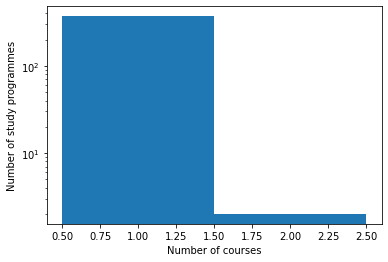

In [8]:
np=[len(p) for p in metadata["programmes"]]
plt.hist(np, bins=[0.5+i for i in range(max(np)+1)])
plt.yscale('log')
plt.ylabel("Number of study programmes")
plt.xlabel("Number of courses")

c=[(metadata["title"][k], len(metadata["programmes"][k])) for k in metadata["programmes"].index if len(metadata["programmes"][k])>1]
print(c)

In [9]:
metadata["ssds"].unique()

array(['ING-INF/01', 'INF/01', 'ING-INF/05', ''], dtype=object)

In [23]:
def plot_tsne_courses(features, metadata, filename,
                      perplexity=30, random_state=42):

    # Ensure same ordering
    metadata = metadata.loc[features.index]

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state
    )

    coords = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(40, 40))

    texts = []

    for i, idx in enumerate(features.index):

        campi = metadata.loc[idx, "campi"]
        ssds = metadata.loc[idx, "ssds"]

        # ----- colour -----
        color = "gray"

        campi_str = str(campi).lower()

        if "cesena" in campi_str:
            color = "green"
        elif "bologna" in campi_str:
            color = "blue"


        # ----- marker -----
        marker = "x"

        ssds_str = str(ssds).upper()

        if "ING-INF/05" in ssds_str:
            marker = "*"
        elif "INF/01" in ssds_str:
            marker = "o"

        ax.scatter(
            coords[i, 0],
            coords[i, 1],
            c=color,
            marker=marker,
            s=120 if marker == "*" else 60,
            alpha=0.8,
        )

        title = metadata.loc[idx, "title"]+ idx

        texts.append(
            ax.text(
                coords[i, 0],
                coords[i, 1],
                title,
                fontsize=8
            )
        )

    adjust_text(
        texts,
        ax=ax,
        force_text=(10, 10),
        force_static=(1,1),
        max_move=10,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            color="gray"
        )
    )

    ax.set_title("Course t-SNE")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    
    legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markersize=10,
           label='Bologna INF/01'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markersize=10,
           label='Cesena INF/01'),

    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='blue', markersize=12,
           label='Bologna ING-INF/05'),

    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='green', markersize=12,
           label='Cesena ING-INF/05'),]

    ax.legend(handles=legend_elements, loc='best')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [24]:
plot_tsne_courses(
    features,
    metadata,
    "courses_tsne.png", perplexity=3
)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/opt/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


In [ ]:
#TODO: check programme, add columns for teacher dpt,
#    programme dpt., make some histograms, clustering, analyse some tight clusters  
    